In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from matplotlib.colors import LinearSegmentedColormap
import shap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle


Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:

# ML models
from openxai.LoadModel import LoadModel

# Data loaders
from openxai.dataloader import return_loaders

# Explanation models
from openxai.Explainer import Explainer

# Evaluation methods
from openxai.evaluator import Evaluator

In [3]:
prefix = '../DATA/EXPLAINER_OUTPUTS/META/'
# data_name = 'german'  # shap and lime @ 0, ig 0.3 rot 1.hhh 
data_name = 'compas'  # acceptable baselines (all ~1.hhh)
# data_name = 'heloc'  # shap and lime @ 0.55, others ~0.hhh
# data_name = 'adult'  # shap and lime @ 2.5, ig -1, rot -0.7
model_name = 'lr'
explainers = ['shap', 'lime', 'ig', 'rot']

explanation_dfs = []
baseline_dfs = []

In [4]:
model = LoadModel(data_name=data_name, ml_model=model_name, pretrained=True)

# Get training and test loaders
loader_train, loader_test = return_loaders(data_name=data_name, download=True, batch_size=1)


data_all = torch.FloatTensor(loader_train.dataset.data)#[:51,:]

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [5]:
y_preds = model(data_all).detach().numpy()[:,1].flatten()


In [6]:
for explainer in explainers:
    df = pd.read_csv(f'{prefix}exp_{data_name}_{model_name}_{explainer}.csv')
    df = df.drop(columns='Unnamed: 0')
    explanation_dfs.append(df)
    df = pd.read_csv(f'{prefix}base_{data_name}_{model_name}_{explainer}.csv')
    df = df.drop(columns='Unnamed: 0')
    baseline_dfs.append(df)


In [7]:
df = pd.DataFrame({'model_proba': model(data_all).detach().numpy()[:,1]})
logit_tensor = model.linear(data_all).detach().numpy()
df['model_logits'] = logit_tensor[:,1] - logit_tensor[:,0]
for exp_df, base_df, explainer in zip(explanation_dfs, baseline_dfs, ['shap', 'lime', 'ig', 'rot']):
    print(f'{explainer} baseline : {np.mean(base_df)}')
    imp_sums = exp_df.sum(axis=1).values.flatten() + base_df.values.flatten()
    df[f'{explainer}_pred'] = imp_sums
    pass
exps = explanation_dfs[0]
baseline = baseline_dfs[0]

shap baseline : 1.0269299
lime baseline : 1.0278198125987443
ig baseline : 1.2375457999999997
rot baseline : 1.0847219000000001


In [8]:
df_sorted = df.sort_values(by='model_logits')

In [9]:
neg_indices = df[df['model_proba'] <= 0.5].index
pos_indices = df[df['model_proba'] > 0.5].index


In [10]:
neg_indices = df[(df['model_proba'] <= 0.5) & (df['model_logits']<=0) & (df['shap_pred']<=0) & (df['rot_pred']<=0)].index
pos_indices = df[(df['model_proba'] > 0.5) & (df['model_logits'] > 0) & (df['shap_pred'] > 0) & (df['rot_pred'] > 0)].index


In [11]:
all_df = loader_train.dataset.X
neg_df = all_df.loc[neg_indices]
pos_df = all_df.loc[pos_indices]


In [12]:
# def select_row(datapoint, df, priority, l0_thresh=2, l1_thresh=4):
def select_row(datapoint, df, priority, l0_thresh=1, l1_thresh=0):
    """
    datapoint: 1D array-like (same length as df columns)
    df: pandas DataFrame
    priority: pandas Series (same index as df)
    l0_thresh: max number of mismatched features allowed
    l1_thresh: minimum L1 distance required
    """

    # Ensure arrays
    x = np.array(datapoint)
    X = df.values

    # L0 distance: number of features that differ
    l0_dist = np.sum(X != x, axis=1)

    # L1 distance: sum of absolute differences
    l1_dist = np.sum(np.abs(X - x), axis=1)

    # Mask: low L0 and high L1
    mask = (l0_dist <= l0_thresh) & (l1_dist >= l1_thresh)

    # If no valid rows, return None
    if not mask.any():
        return None


    # Subset + sort by priority
    candidates = priority[mask].sort_values(ascending=False)

    # Return index of highest-priority candidate
    return candidates.index[0]


In [13]:
cf_indices = []
f_indices = []

for fact_index, fact_row in zip(neg_df.index, neg_df.values):
    cf_index = select_row(fact_row, pos_df, df.loc[pos_indices]['model_logits'])
    if cf_index is not None:
        cf_indices.append(cf_index)
        f_indices.append(fact_index)


In [14]:
f_datapoints = neg_df.loc[f_indices].copy()


In [15]:

cf_datapoints = pos_df.loc[cf_indices].copy()


In [16]:
f_shap = explanation_dfs[0].loc[f_datapoints.index]
cf_shap = explanation_dfs[0].loc[cf_datapoints.index]

f_lime = explanation_dfs[1].loc[f_datapoints.index]
cf_lime = explanation_dfs[1].loc[cf_datapoints.index]

f_ig = explanation_dfs[2].loc[f_datapoints.index]
cf_ig = explanation_dfs[2].loc[cf_datapoints.index]

f_rot = explanation_dfs[3].loc[f_datapoints.index]
cf_rot = explanation_dfs[3].loc[cf_datapoints.index]

In [17]:
b_f_shap = baseline_dfs[0].loc[f_datapoints.index]
b_cf_shap = baseline_dfs[0].loc[cf_datapoints.index]

b_f_lime = baseline_dfs[1].loc[f_datapoints.index]
b_cf_lime = baseline_dfs[1].loc[cf_datapoints.index]

b_f_ig = baseline_dfs[2].loc[f_datapoints.index]
b_cf_ig = baseline_dfs[2].loc[cf_datapoints.index]

b_f_rot = baseline_dfs[3].loc[f_datapoints.index]
b_cf_rot = baseline_dfs[3].loc[cf_datapoints.index]

In [18]:
def imp_normalize(df, norms=False):
    if not norms:
        return df
    result = df.values.T / df.abs().sum(axis=1).values.T
    return pd.DataFrame(result.T, columns=df.columns)

In [19]:
feature_data = {}
norms = False
for feature_name in loader_train.dataset.feature_names:
    data_dict = {
        'f_shaps': imp_normalize(f_shap, norms=norms)[feature_name].values,
        'cf_shaps': imp_normalize(cf_shap, norms=norms)[feature_name].values,
        'f_limes': imp_normalize(f_lime, norms=norms)[feature_name].values,
        'cf_limes': imp_normalize(cf_lime, norms=norms)[feature_name].values,
        'f_igs': imp_normalize(f_ig, norms=norms)[feature_name].values,
        'cf_igs': imp_normalize(cf_ig, norms=norms)[feature_name].values,
        'f_rots': imp_normalize(f_rot, norms=norms)[feature_name].values,
        'cf_rots': imp_normalize(cf_rot, norms=norms)[feature_name].values,
        'f_val': f_datapoints[feature_name].values,
        'cf_val': cf_datapoints[feature_name].values,
    }
    _df = pd.DataFrame(data_dict)
    _df['feature_delta'] = _df['cf_val'] - _df['f_val']
    _df['shap_delta'] = _df['cf_shaps'] - _df['f_shaps']
    _df['lime_delta'] = _df['cf_limes'] - _df['f_limes']
    _df['ig_delta'] = _df['cf_igs'] - _df['f_igs']
    _df['rot_delta'] = _df['cf_rots'] - _df['f_rots']
    feature_data[feature_name] = _df


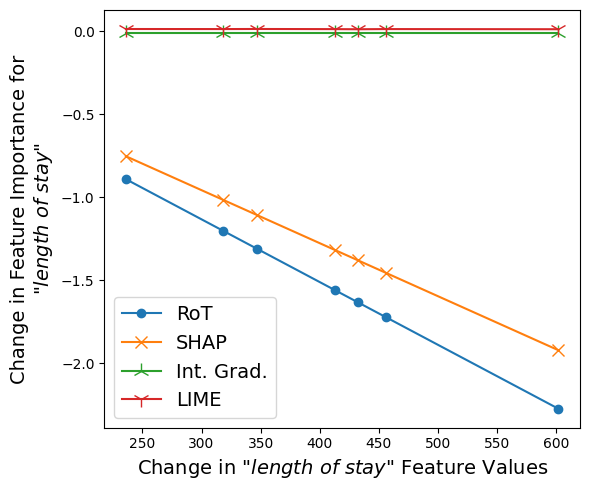

In [20]:
for k in feature_data:
    if k != 'length_of_stay':
        continue
        # pass
    plt.figure(figsize=(6,5))
    _df = feature_data[k]
    _df = _df[_df['feature_delta'] != 0]
    _df = _df.sort_values(by='feature_delta')
    # plt.title(k)
    plt.plot(-_df['feature_delta'], -_df['rot_delta'], label='RoT', marker='.', alpha=1, markersize=12)
    plt.plot(-_df['feature_delta'], -_df['shap_delta'], label='SHAP', marker='x', alpha=1, markersize=9)
    plt.plot(-_df['feature_delta'], -_df['ig_delta']-0.013, label='Int. Grad.', marker='2', alpha=1, markersize=12, zorder=-2)
    plt.plot(-_df['feature_delta'], -_df['lime_delta']+0.013, label='LIME', marker='1', alpha=1, markersize=12, zorder=1)
    plt.legend(fontsize=14)
    plt.xlabel('Change in "$length$ $of$ $stay$" Feature Values', fontsize=14)
    plt.ylabel('Change in Feature Importance for\n"$length$ $of$ $stay$"', fontsize=14)
    plt.tight_layout()
    plt.savefig('../PLOTS/OpenXAI_COMPAS_scatter.pdf', dpi=300)
    plt.show()